# ANÁLISE COM PCA E MDS: VOOS ATRASADOS POR CONDIÇÕES CLIMÁTICAS
================================================================

### Dataset real:
https://www.kaggle.com/datasets/ioanagheorghiu/historical-flight-and-weather-data

## Problema:
Investigar como condições climáticas e fatores regionais influenciam atrasos de voos.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [58]:
df = pd.read_csv("archive/flights_12_2019.csv")

print("Shape:", df.shape)
print(df.head())

print("\nColunas:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (679996, 35)
  carrier_code  flight_number origin_airport destination_airport        date  \
0           AA           4717            PHL                 ABE  2019-12-01   
1           AA           4887            PHL                 AVP  2019-12-01   
2           AA           2626            CLT                 BNA  2019-12-01   
3           AA           3269            PHX                 SBP  2019-12-01   
4           AA            759            CLT                 MEM  2019-12-01   

   scheduled_elapsed_time tail_number  departure_delay  arrival_delay  \
0                      40      N628AE               -7            -10   
1                      52      N683AE               -8            -14   
2                      86      N176UW               15             15   
3                      99      N750SK               19             44   
4                     111      N740UW                0              4   

   delay_carrier  ...  HourlyPrecipitation_x  HourlyStationP

In [59]:
df.head(5)

,carrier_code,flight_number,origin_airport,destination_airport,date,scheduled_elapsed_time,tail_number,departure_delay,arrival_delay,delay_carrier,...,HourlyPrecipitation_x,HourlyStationPressure_x,HourlyVisibility_x,HourlyWindSpeed_x,STATION_y,HourlyDryBulbTemperature_y,HourlyPrecipitation_y,HourlyStationPressure_y,HourlyVisibility_y,HourlyWindSpeed_y
0,AA,4717,PHL,ABE,2019-12-01,40,N628AE,-7,-10,0,...,0.00,29.96,10.0,3.0,7.251701e+10,28.0,0.0,29.58,10.0,0.0
1,AA,4887,PHL,AVP,2019-12-01,52,N683AE,-8,-14,0,...,0.00,29.96,10.0,3.0,7.251301e+10,26.0,0.0,28.94,10.0,3.0
2,AA,2626,CLT,BNA,2019-12-01,86,N176UW,15,15,9,...,0.01,29.06,4.0,6.0,7.232701e+10,65.0,0.0,28.92,10.0,13.0
3,AA,3269,PHX,SBP,2019-12-01,99,N750SK,19,44,19,...,0.00,28.93,10.0,5.0,7.228979e+10,52.0,0.0,29.79,10.0,6.0
4,AA,759,CLT,MEM,2019-12-01,111,N740UW,0,4,0,...,0.26,29.11,4.0,6.0,7.233401e+10,56.0,0.0,29.33,10.0,9.0


O dataset contém:
- Informações de voos (atrasos, distância, duração)
- Dados meteorológicos (temperatura, vento, visibilidade, precipitação)
- Informações regionais (origem/destino)

In [60]:
features = [
    "departure_delay",        # atraso na partida
    "arrival_delay",        # atraso na chegada
    "HourlyDryBulbTemperature_y",             # temperatura
    "HourlyWindSpeed_y",       # vento
    "HourlyVisibility_y",       # visibilidade
    "HourlyPrecipitation_y",    # chuva
]

# Feature categórica
category = "origin_airport"

df_selected = df[features + [category]].dropna()

print("Shape após seleção:", df_selected.shape)

Shape após seleção: (678841, 7)


In [61]:
X = df_selected[features]

z_scores = np.abs(zscore(X))
mask = (z_scores < 3).all(axis=1)

X = X[mask]
df_selected = df_selected[mask]

print("Após remoção de outliers:", X.shape)

Após remoção de outliers: (627302, 6)


In [62]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dados padronizados")

Dados padronizados


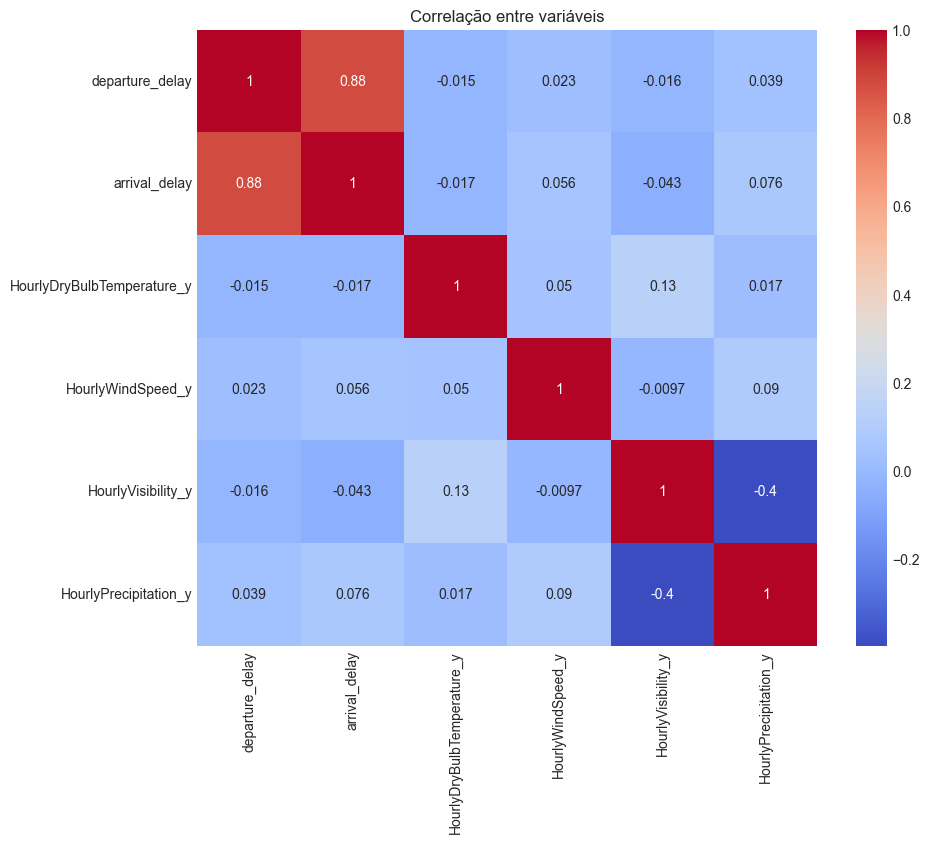

In [63]:
corr = pd.DataFrame(X_scaled, columns=features).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis")
plt.show()

In [64]:
#PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cum = np.cumsum(explained)

print("\nVariância explicada:")
for i, v in enumerate(explained[:5]):
    print(f"PC{i+1}: {v:.2f}")

# PCA 2D
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

print("\nVariância total (2D):", pca2.explained_variance_ratio_.sum())



Variância explicada:
PC1: 0.32
PC2: 0.23
PC3: 0.18
PC4: 0.15
PC5: 0.10

Variância total (2D): 0.5503625353252618


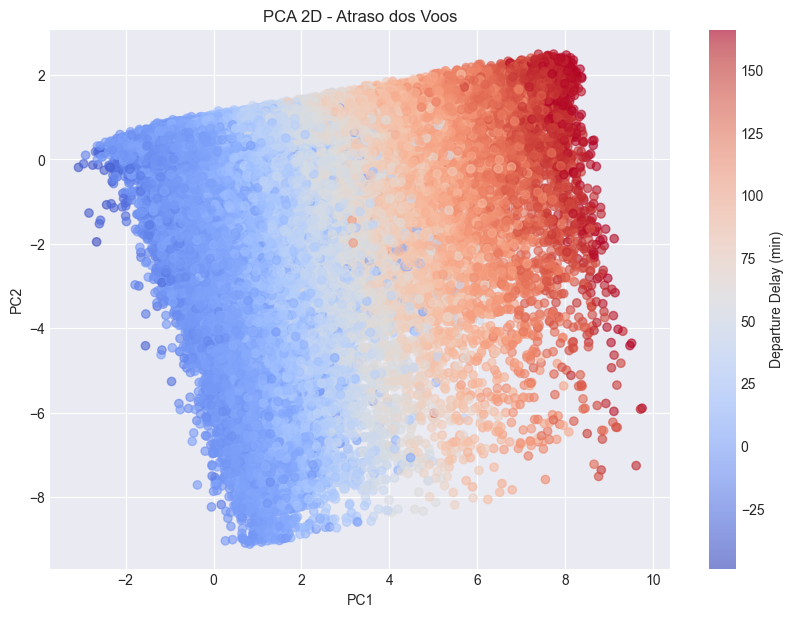

                                 PC1       PC2
departure_delay             0.949806  0.186199
arrival_delay               0.958393  0.142349
HourlyDryBulbTemperature_y -0.047891  0.202503
HourlyWindSpeed_y           0.103010 -0.140297
HourlyVisibility_y         -0.159271  0.819213
HourlyPrecipitation_y       0.202201 -0.784628


In [65]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca2[:,0],
    X_pca2[:,1],
    c=df_selected["departure_delay"],
    cmap='coolwarm',
    alpha=0.6
)

plt.title("PCA 2D - Atraso dos Voos")
plt.xlabel("PC1")
plt.ylabel("PC2")

cbar = plt.colorbar()
cbar.set_label("Departure Delay (min)")

plt.show()

loadings = pd.DataFrame(
    pca2.components_.T * np.sqrt(pca2.explained_variance_),
    columns=["PC1", "PC2"],
    index=features
)

print(loadings)

In [66]:
#subsample
# Limitar tamanho para MDS
sample_size = 2000  # pode testar 1000–3000

if X_scaled.shape[0] > sample_size:
    idx = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
    X_mds_input = X_scaled[idx]
    df_mds_ref = df_selected.iloc[idx]
else:
    X_mds_input = X_scaled
    df_mds_ref = df_selected

In [67]:
dist = squareform(pdist(X_mds_input))

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
X_mds = mds.fit_transform(dist)

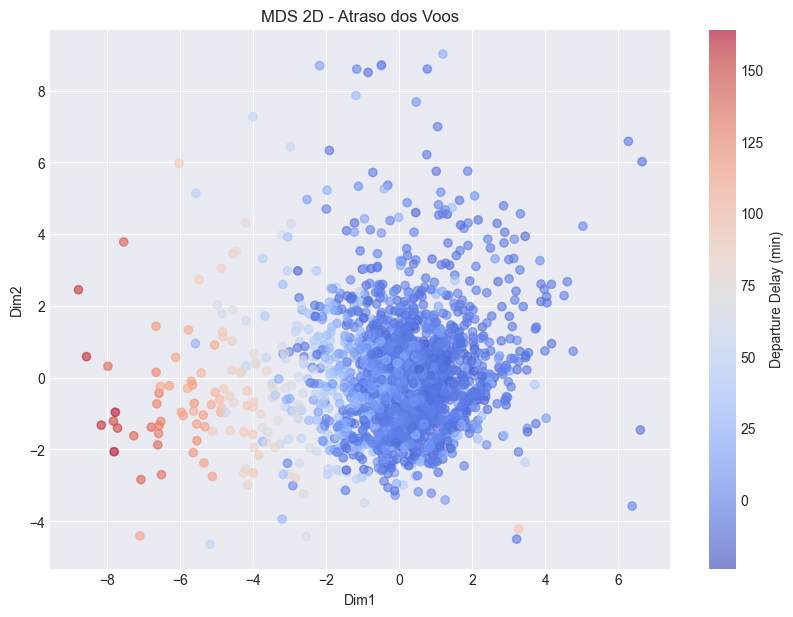

In [68]:
colors = df_mds_ref["departure_delay"].values

plt.figure(figsize=(10,7))

sc = plt.scatter(
    X_mds[:, 0],
    X_mds[:, 1],
    c=colors,
    cmap='coolwarm',   # melhor para interpretação
    alpha=0.6
)

plt.title("MDS 2D - Atraso dos Voos")
plt.xlabel("Dim1")
plt.ylabel("Dim2")

cbar = plt.colorbar(sc)
cbar.set_label("Departure Delay (min)")

plt.show()

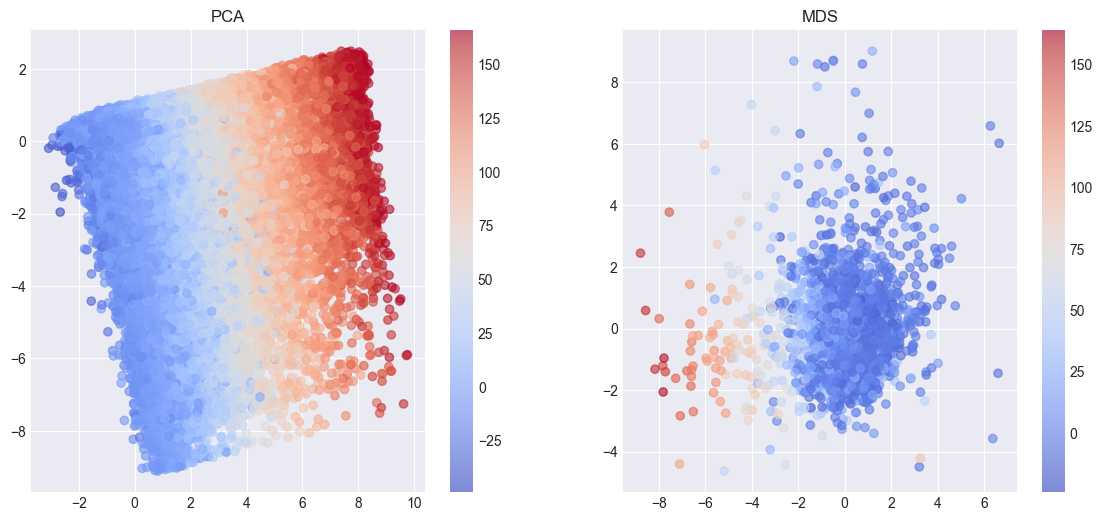

In [70]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

# 🔵 PCA (dataset completo)
colors_pca = df_selected["departure_delay"].values

sc1 = ax[0].scatter(
    X_pca2[:,0],
    X_pca2[:,1],
    c=colors_pca,
    cmap='coolwarm',
    alpha=0.6
)
ax[0].set_title("PCA")

# 🔴 MDS (amostra)
colors_mds = df_mds_ref["departure_delay"].values

sc2 = ax[1].scatter(
    X_mds[:,0],
    X_mds[:,1],
    c=colors_mds,
    cmap='coolwarm',
    alpha=0.6
)
ax[1].set_title("MDS")

plt.colorbar(sc1, ax=ax[0])
plt.colorbar(sc2, ax=ax[1])

plt.show()